<a href="https://colab.research.google.com/github/aksaini175/Cognifyz-Internship-Level-3/blob/main/task_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df = pd.read_csv("/Dataset .csv")


In [4]:
df.info(), df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

(None,
    Restaurant ID         Restaurant Name  Country Code              City  \
 0        6317637        Le Petit Souffle           162       Makati City   
 1        6304287        Izakaya Kikufuji           162       Makati City   
 2        6300002  Heat - Edsa Shangri-La           162  Mandaluyong City   
 3        6318506                    Ooma           162  Mandaluyong City   
 4        6314302             Sambo Kojin           162  Mandaluyong City   
 
                                              Address  \
 0  Third Floor, Century City Mall, Kalayaan Avenu...   
 1  Little Tokyo, 2277 Chino Roces Avenue, Legaspi...   
 2  Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...   
 3  Third Floor, Mega Fashion Hall, SM Megamall, O...   
 4  Third Floor, Mega Atrium, SM Megamall, Ortigas...   
 
                                      Locality  \
 0   Century City Mall, Poblacion, Makati City   
 1  Little Tokyo, Legaspi Village, Makati City   
 2  Edsa Shangri-La, Ortigas, Manda

**Analyze the Text Reviews to Identify the Most Common Positive and Negative Keywords**

In [5]:
rating_counts = df["Rating text"].value_counts()

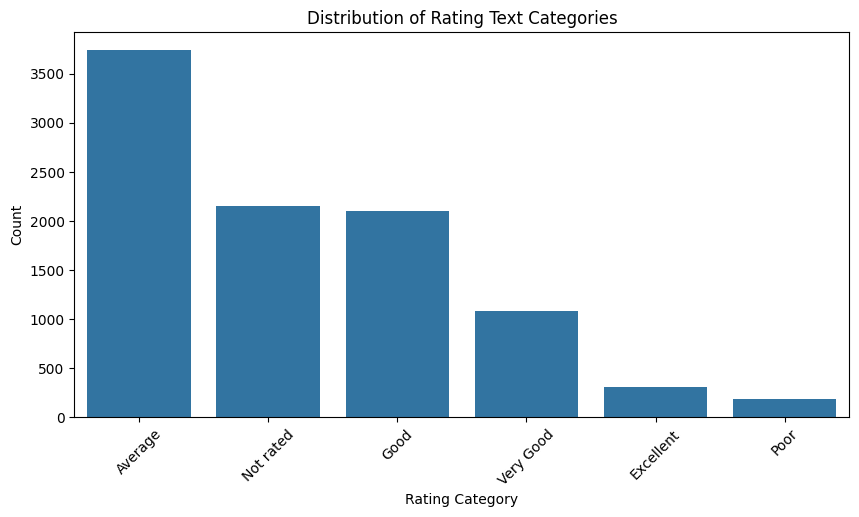

In [6]:
plt.figure(figsize=(10,5))
sns.barplot(x=rating_counts.index, y=rating_counts.values)
plt.xticks(rotation=45)
plt.xlabel("Rating Category")
plt.ylabel("Count")
plt.title("Distribution of Rating Text Categories")
plt.show()

In [7]:
rating_counts

,count
Rating text,
Average,3737
Not rated,2148
Good,2100
Very Good,1079
Excellent,301
Poor,186


In [8]:
from collections import Counter

In [9]:
positive_ratings = ["Excellent", "Very Good", "Good"]
negative_ratings = ["Average", "Poor"]

In [10]:
positive_words = " ".join(df[df["Rating text"].isin(positive_ratings)]["Rating text"]).lower().split()
negative_words = " ".join(df[df["Rating text"].isin(negative_ratings)]["Rating text"]).lower().split()

In [11]:
positive_word_counts = Counter(positive_words).most_common(5)
negative_word_counts = Counter(negative_words).most_common(5)

positive_word_counts, negative_word_counts

([('good', 3179), ('very', 1079), ('excellent', 301)],
 [('average', 3737), ('poor', 186)])

**Calculate the Average Length of Reviews and Explore if There is a Relationship Between Review Length and Rating.**

In [12]:
df["Rating text length"] = df["Rating text"].apply(lambda x: len(x.split()))

In [13]:
average_length = df["Rating text length"].mean()

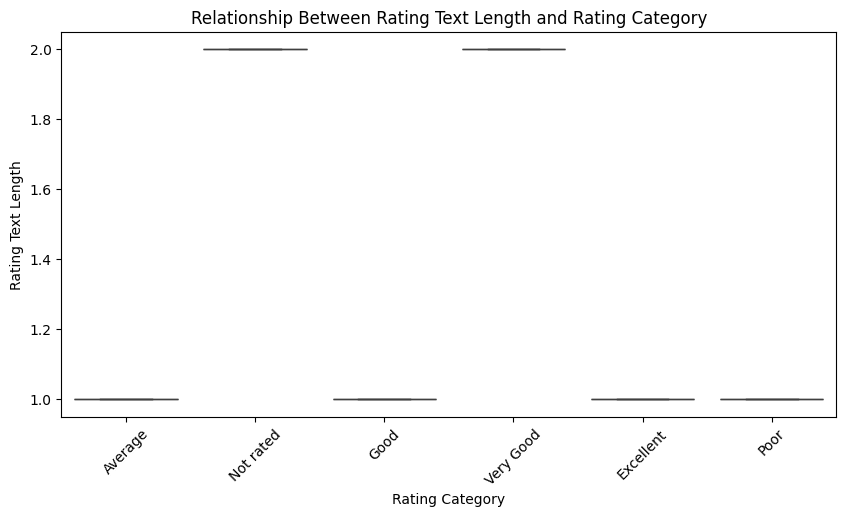

np.float64(1.3378703800649148)

In [14]:
plt.figure(figsize=(10, 5))
sns.boxplot(x="Rating text", y="Rating text length", data=df, order=rating_counts.index)
plt.xticks(rotation=45)
plt.xlabel("Rating Category")
plt.ylabel("Rating Text Length")
plt.title("Relationship Between Rating Text Length and Rating Category")
plt.show()

average_length